In [1]:
# csherwood@usgs.gov, 2026-08-20, generated with Sonnet 4.6

import xarray as xr

fn_ff = r"F:\crs\proj\2025_NOPP_comparison\helene_scripps_drifters\LDL_FIRSTFIVE_HELENE.nc"
fn_sensor = r"F:\crs\proj\2025_NOPP_comparison\helene_scripps_drifters\LDL_SENSOR_HELENE.nc"

ds_ff = xr.open_dataset(fn_ff)
ds_sensor = xr.open_dataset(fn_sensor)

In [2]:
ds_ff

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 33363)
Coordinates:
  * time         (time) datetime64[ns] 267kB 2024-09-30T15:00:00 ... 2024-09-...
Data variables:
    platform_ID  (time) int64 267kB ...
    frequency    (time) float32 133kB ...
    a0           (time) float32 133kB ...
    a1           (time) float32 133kB ...
    b1           (time) float32 133kB ...
    a2           (time) float32 133kB ...
    b2           (time) float32 133kB ...
Attributes: (12/21)
    title:                     First-Five File - NOPP DWSD HELENE
    Conventions:               COARDS, CF-1.6, ACDD-1.3
    creator_country:           USA
    creator_institution:       SIO/UCSD
    creator_name:              LDL
    creator_sector:            academic
    ...                        ...
    summary:                   DWSD first-five data from HELENE.
    time_coverage_start:       24-Sep-2024 21:16:00Z
    time_coverage_end:         30-Sep-2024 15:00:00Z
    reference_doi:             https://doi.org/10.17603/ds2-8x65-ne87
    acknowledgement:           Schonau, M., L. Centurioni (2025). "Directiona...
    funding_award:             ON00014-21-1-2199

In [5]:
ds_sensor

<xarray.Dataset> Size: 201kB
Dimensions:                      (time: 2014)
Coordinates:
  * time                         (time) datetime64[ns] 16kB 2024-10-02T21:00:...
Data variables: (12/22)
    platform_ID                  (time) int64 16kB ...
    latitude                     (time) float32 8kB ...
    longitude                    (time) float32 8kB ...
    significant_wave_height      (time) float32 8kB ...
    sea_surface_temperature      (time) float32 8kB ...
    sea_level_pressure           (time) float32 8kB ...
    ...                           ...
    wave_qcflag7                 (time) float32 8kB ...
    wave_qcflag8                 (time) float32 8kB ...
    wave_qcflag9                 (time) float32 8kB ...
    wave_qcflag10                (time) float32 8kB ...
    wave_qcflag11                (time) float32 8kB ...
    wave_qcflag12                (time) float32 8kB ...
Attributes: (12/21)
    title:                     Sensor File - NOPP DWSD HELENE
    Conventions:               COARDS, CF-1.6, ACDD-1.3
    creator_country:           USA
    creator_institution:       SIO/UCSD
    creator_name:              LDL
    creator_sector:            academic
    ...                        ...
    standard_name_vocabulary:  CF Standard Name Table v70
    summary:                   DWSD sensor data from HELENE.
    time_coverage_start:       19-Sep-2024 03:00:00Z
    time_coverage_end:         02-Oct-2024 21:00:00Z
    reference_doi:             https://doi.org/10.17603/ds2-8x65-ne87
    acknowledgement:           Schonau, M., L. Centurioni (2025). "Directiona...

In [6]:
# split into dict of per-drifter DataFrames, sorted by time, keyed by platform_ID
df_sensor_all = ds_sensor.to_dataframe()
drifter_ids = sorted(df_sensor_all['platform_ID'].unique())

sensor = {}
for pid in drifter_ids:
    df = df_sensor_all[df_sensor_all['platform_ID'] == pid].sort_index()
    sensor[pid] = df

drifter_ids

[np.int64(300534061904680),
 np.int64(300534061904690),
 np.int64(300534061904700),
 np.int64(300534061904750),
 np.int64(300534061904760),
 np.int64(300534061904800),
 np.int64(300534061905080)]

In [7]:
# split first-five into dict of per-drifter DataFrames, keyed by platform_ID
df_ff_all = ds_ff.to_dataframe()

firstfive = {}
for pid in drifter_ids:
    df = df_ff_all[df_ff_all['platform_ID'] == pid].sort_index()
    firstfive[pid] = df

for pid, df in firstfive.items():
    print(pid, df.index.min(), df.index.max(), len(df), df['frequency'].nunique(), 'freqs')

300534061904680 2024-09-27 04:30:00 2024-09-30 15:00:00 9813 60 freqs
300534061904690 NaT NaT 0 0 freqs
300534061904700 2024-09-28 05:29:59.999996672 2024-09-30 13:30:00 6686 60 freqs
300534061904750 2024-09-30 13:30:00 2024-09-30 13:30:00 33 33 freqs
300534061904760 2024-09-30 09:30:00.000003328 2024-09-30 15:00:00 571 60 freqs
300534061904800 NaT NaT 0 0 freqs
300534061905080 2024-09-24 21:16:00.000003072 2024-09-30 13:30:00 16260 60 freqs


In [8]:
# reshape one drifter's first-five into (time x frequency) spectral matrices
def pivot_spectrum(df):
    out = {}
    for var in ['a0', 'a1', 'b1', 'a2', 'b2']:
        out[var] = df.reset_index().pivot_table(index='time', columns='frequency', values=var)
    return out

spec = {pid: pivot_spectrum(df) for pid, df in firstfive.items()}

In [9]:
# check shape and Hs recovery: Hs = 4*sqrt(m0), m0 = sum(a0*df) over freq band
pid = drifter_ids[0]
spec[pid]['a0'].shape, spec[pid]['a0'].columns.values[:5], spec[pid]['a0'].columns.values[-5:]

((164, 60),
 array([0.03125  , 0.0390625, 0.046875 , 0.0546875, 0.0625   ],
       dtype=float32),
 array([0.460938, 0.46875 , 0.476562, 0.484375, 0.492188], dtype=float32))

C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS11\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS11\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


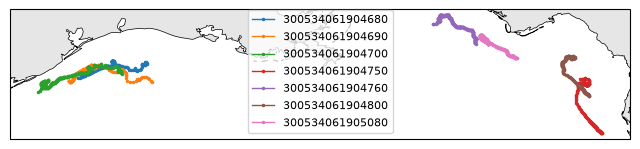

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

valid_ids = [pid for pid in drifter_ids if len(sensor[pid]) > 0]


fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, lw=0.5)
ax.add_feature(cfeature.LAND, facecolor='0.9')
for pid in valid_ids:
    df = sensor[pid]
    ax.plot(df['longitude'], df['latitude'], lw=1, marker='.', ms=3, label=str(pid), transform=ccrs.PlateCarree())
ax.legend(fontsize=8)